# Getting started with ztforce

This notebook walks through the core workflow: running forced PSF photometry at a fixed sky position, inspecting the resulting lightcurve, and saving it to disk.

**Prerequisites:** install ztforce and set your IRSA credentials (see the [installation docs](https://ztforce.readthedocs.io)).

```bash
pip install ztforce
export ZTFORCE_IRSA_USER=you@example.com
export ZTFORCE_IRSA_PASS=secret
```

## Run forced photometry

`run_forced_photometry` is the main entry point. Pass an RA/Dec (decimal degrees, J2000) and a list of bands. It returns a dict mapping band → `Lightcurve`.

In [1]:
from ztforce import run_forced_photometry

# Bright star near Praesepe (M44) — PS1 g = 15.82
lcs = run_forced_photometry(
    ra=130.13113,
    dec=19.69525,
    bands=["g", "r"],
    max_epochs=50,  # cap to the 50 most recent epochs for a quick demo
)
print(lcs)

{'g': Lightcurve(ra=130.13113, dec=19.69525, n_epochs=50, bands=['g']), 'r': Lightcurve(ra=130.13113, dec=19.69525, n_epochs=50, bands=['r'])}


## Inspect the lightcurve DataFrame

Each `Lightcurve` exposes its data as a pandas DataFrame via `.df`. The `detection` column flags epochs with SNR ≥ 3; `upper_limit` gives the 5σ limiting magnitude for non-detections.

In [2]:
lc_g = lcs["g"]
df = lc_g.df
print(df.columns.tolist())
df[["obsjd", "mag", "mag_err", "snr", "detection", "flags"]].head(10)

['obsjd', 'band', 'flux', 'flux_err', 'mag', 'mag_err', 'zero_point', 'flags', 'snr', 'detection', 'upper_limit', 'x_fit', 'y_fit', 'image_id']


,obsjd,mag,mag_err,snr,detection,flags
0,2.461005e+06,15.830419,0.006549,165.780296,True,0
1,2.461007e+06,15.907963,0.008592,126.368260,True,0
2,2.461009e+06,15.931780,0.006054,179.356536,True,0
3,2.461011e+06,15.755216,0.005361,202.525271,True,0
4,2.461016e+06,15.505768,0.008269,131.298511,True,0
5,2.461021e+06,15.773417,0.008637,125.709012,True,0
6,2.461023e+06,15.624690,0.005705,190.324991,True,0
7,2.461026e+06,15.707904,0.005504,197.265814,True,0
8,2.461028e+06,16.066174,0.006375,170.312528,True,0
9,2.461030e+06,15.945395,0.005522,196.633149,True,0


## Plot

Use the `.df` property to access the underlying DataFrame and plot with matplotlib directly.
The `detection` column flags epochs with SNR ≥ 3; `upper_limit` gives the 5σ limiting magnitude for non-detections.

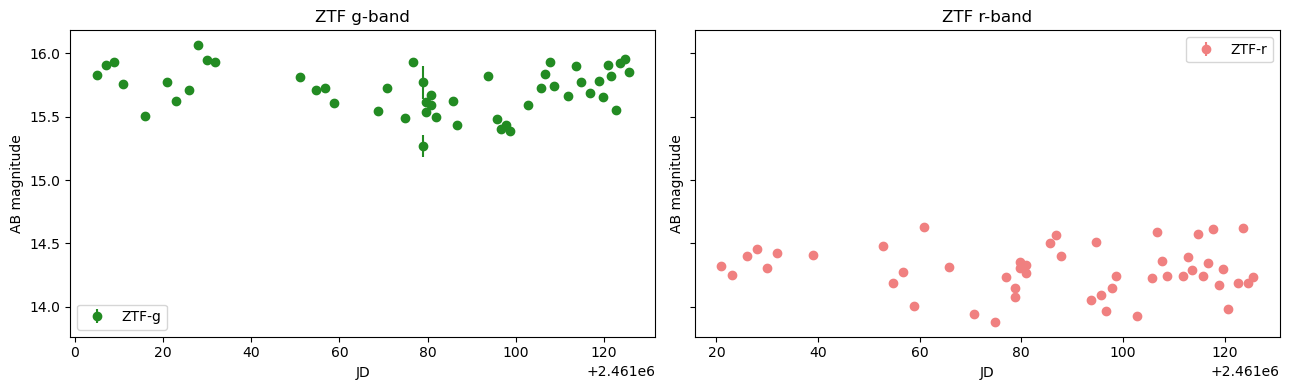

In [3]:
import matplotlib.pyplot as plt
import numpy as np

BAND_COLORS = {"g": "forestgreen", "r": "lightcoral"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, band in zip(axes, ["g", "r"]):
    df = lcs[band].df
    color = BAND_COLORS[band]
    det = df[df["detection"]]
    non_det = df[~df["detection"] & np.isfinite(df["upper_limit"])]

    ax.errorbar(det["obsjd"], det["mag"], yerr=det["mag_err"], fmt="o", color=color, label=f"ZTF-{band}")
    ax.errorbar(
        non_det["obsjd"], non_det["upper_limit"], yerr=0.2, uplims=True, fmt="none", color=color, alpha=0.4
    )
    ax.invert_yaxis()
    ax.set_xlabel("JD")
    ax.set_ylabel("AB magnitude")
    ax.set_title(f"ZTF {band}-band")
    ax.legend()

plt.tight_layout()
plt.show()

## Stack detections

`.stack()` computes an inverse-variance-weighted (IVW) combination of all clean detections, returning a DataFrame indexed by band.

In [4]:
lc_g.stack()

,flux_stack,flux_err_stack,mag_stack,mag_err_stack,n_epochs
band,,,,,
g,16788.431276,13.713168,15.809848,0.000887,50


You can restrict the stack to a JD window, e.g. to compare pre- and post-outburst brightness:

```python
lc_g.stack(jd_min=2460000, jd_max=2460200)
```

For a sliding window stack use `.rolling_stack(window=30)` (window in days).

## Save and reload

Lightcurves are serialised as Astropy ECSV files, which preserve column types and source coordinates.

In [5]:
from ztforce import Lightcurve

lc_g.save("my_source_g.ecsv")

lc_reloaded = Lightcurve.load("my_source_g.ecsv")
print(lc_reloaded)

Lightcurve(ra=130.13113, dec=19.69525, n_epochs=50, bands=['g'])


## Batch mode

To run on many targets at once, pass a list of `SkyCoord` objects to `run_forced_photometry_batch`:

FITS cutouts are shared automatically when multiple targets fall on the same image.

In [6]:
from astropy.coordinates import SkyCoord
from ztforce import run_forced_photometry_batch

In [ ]:
targets = SkyCoord(ra=[130.13, 210.08, 130.086221], dec=[19.70, -6.88, 19.735330], unit="deg")
results = run_forced_photometry_batch(targets, bands=["g", "r"])
results

Sources:   0%|          | 0/3 [00:00<?, ?source/s]

(130.086, 19.735) [g] downloading:   0%|          | 0/1134 [00:00<?, ?step/s]

(130.086, 19.735) [r] downloading:   0%|          | 0/2518 [00:00<?, ?step/s]

[{'g': Lightcurve(ra=130.13000, dec=19.70000, n_epochs=565, bands=['g']),
  'r': Lightcurve(ra=130.13000, dec=19.70000, n_epochs=1258, bands=['r'])},
 {'g': Lightcurve(ra=210.08000, dec=-6.88000, n_epochs=329, bands=['g']),
  'r': Lightcurve(ra=210.08000, dec=-6.88000, n_epochs=557, bands=['r'])},
 {'g': Lightcurve(ra=130.08622, dec=19.73533, n_epochs=565, bands=['g']),
  'r': Lightcurve(ra=130.08622, dec=19.73533, n_epochs=1258, bands=['r'])}]